<a href="https://colab.research.google.com/github/mugalan/intrinsic-rigid-body-control-estimation/blob/main/rigid-body-control/Twin_Rotor_Attitude_Tracking_DHSM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Initialization

In [ ]:
import numpy as np
import scipy as sp
from scipy.integrate import odeint
import math
from numpy import linalg
import sympy
from sympy import symbols
from sympy import *

import plotly.graph_objects as go
import plotly.express as px
from sympy.physics.mechanics import dynamicsymbols, init_vprinting
from IPython.display import display, Math, Latex

In [ ]:
# Install the simulation helpers
!pip install --quiet "git+https://github.com/mugalan/classical-mechanics-from-a-geometric-point-of-view.git#egg=rigid-body-sim"
import sims
mr = sims.RigidBodySim()

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


#Twin Rotor Model

In [ ]:
alpha, theta, phi, gamma, R, Omega, I = dynamicsymbols("alpha, theta, phi,gamma, R, Omega, I")
init_vprinting
t, I_1, I_2, I_3, l= symbols('t, I_1, I_2, I_3, l')
init_vprinting()

In [ ]:
dtheta = theta.diff(t);ddtheta = dtheta.diff(t)
dalpha = alpha.diff(t);ddalpha = dalpha.diff(t)
dgamma = gamma.diff(t);ddamma = dgamma.diff(t)
dphi = phi.diff(t);ddphi = dphi.diff(t)


R1_phi = Matrix([[1, 0, 0],[0, cos(phi), -sin(phi)],[0, sin(phi),cos(phi)]])
R3_alpha = Matrix([[cos(alpha),-sin(alpha),0],[sin(alpha),cos(alpha),0],[0,0,1]])
R1_gamma = Matrix([[1, 0, 0],[0, cos(gamma), -sin(gamma)],[0, sin(gamma),cos(gamma)]])
R3_theta = Matrix([[cos(theta),-sin(theta),0],[sin(theta),cos(theta),0],[0,0,1]])

In [ ]:
R1_phi

In [ ]:
II = Matrix([[I_1, 0, 0],[0, I_2, 0],[0,0,I_3]])

In [ ]:
II

Image Credits: Bhashitha Maduranga Nawaratne bhashitha614@gmail.com

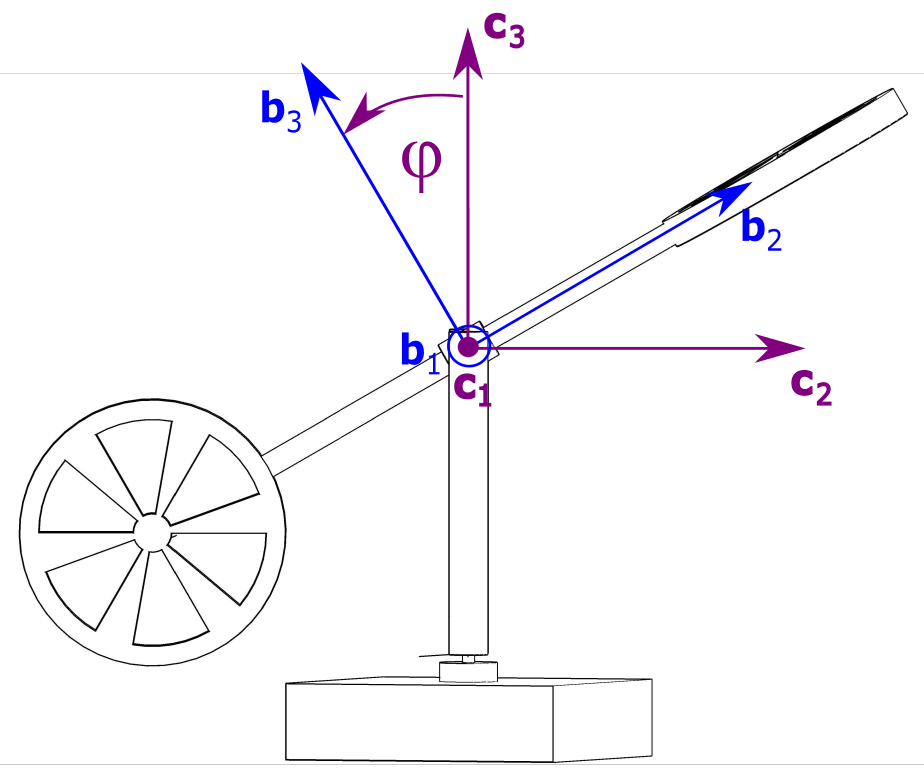

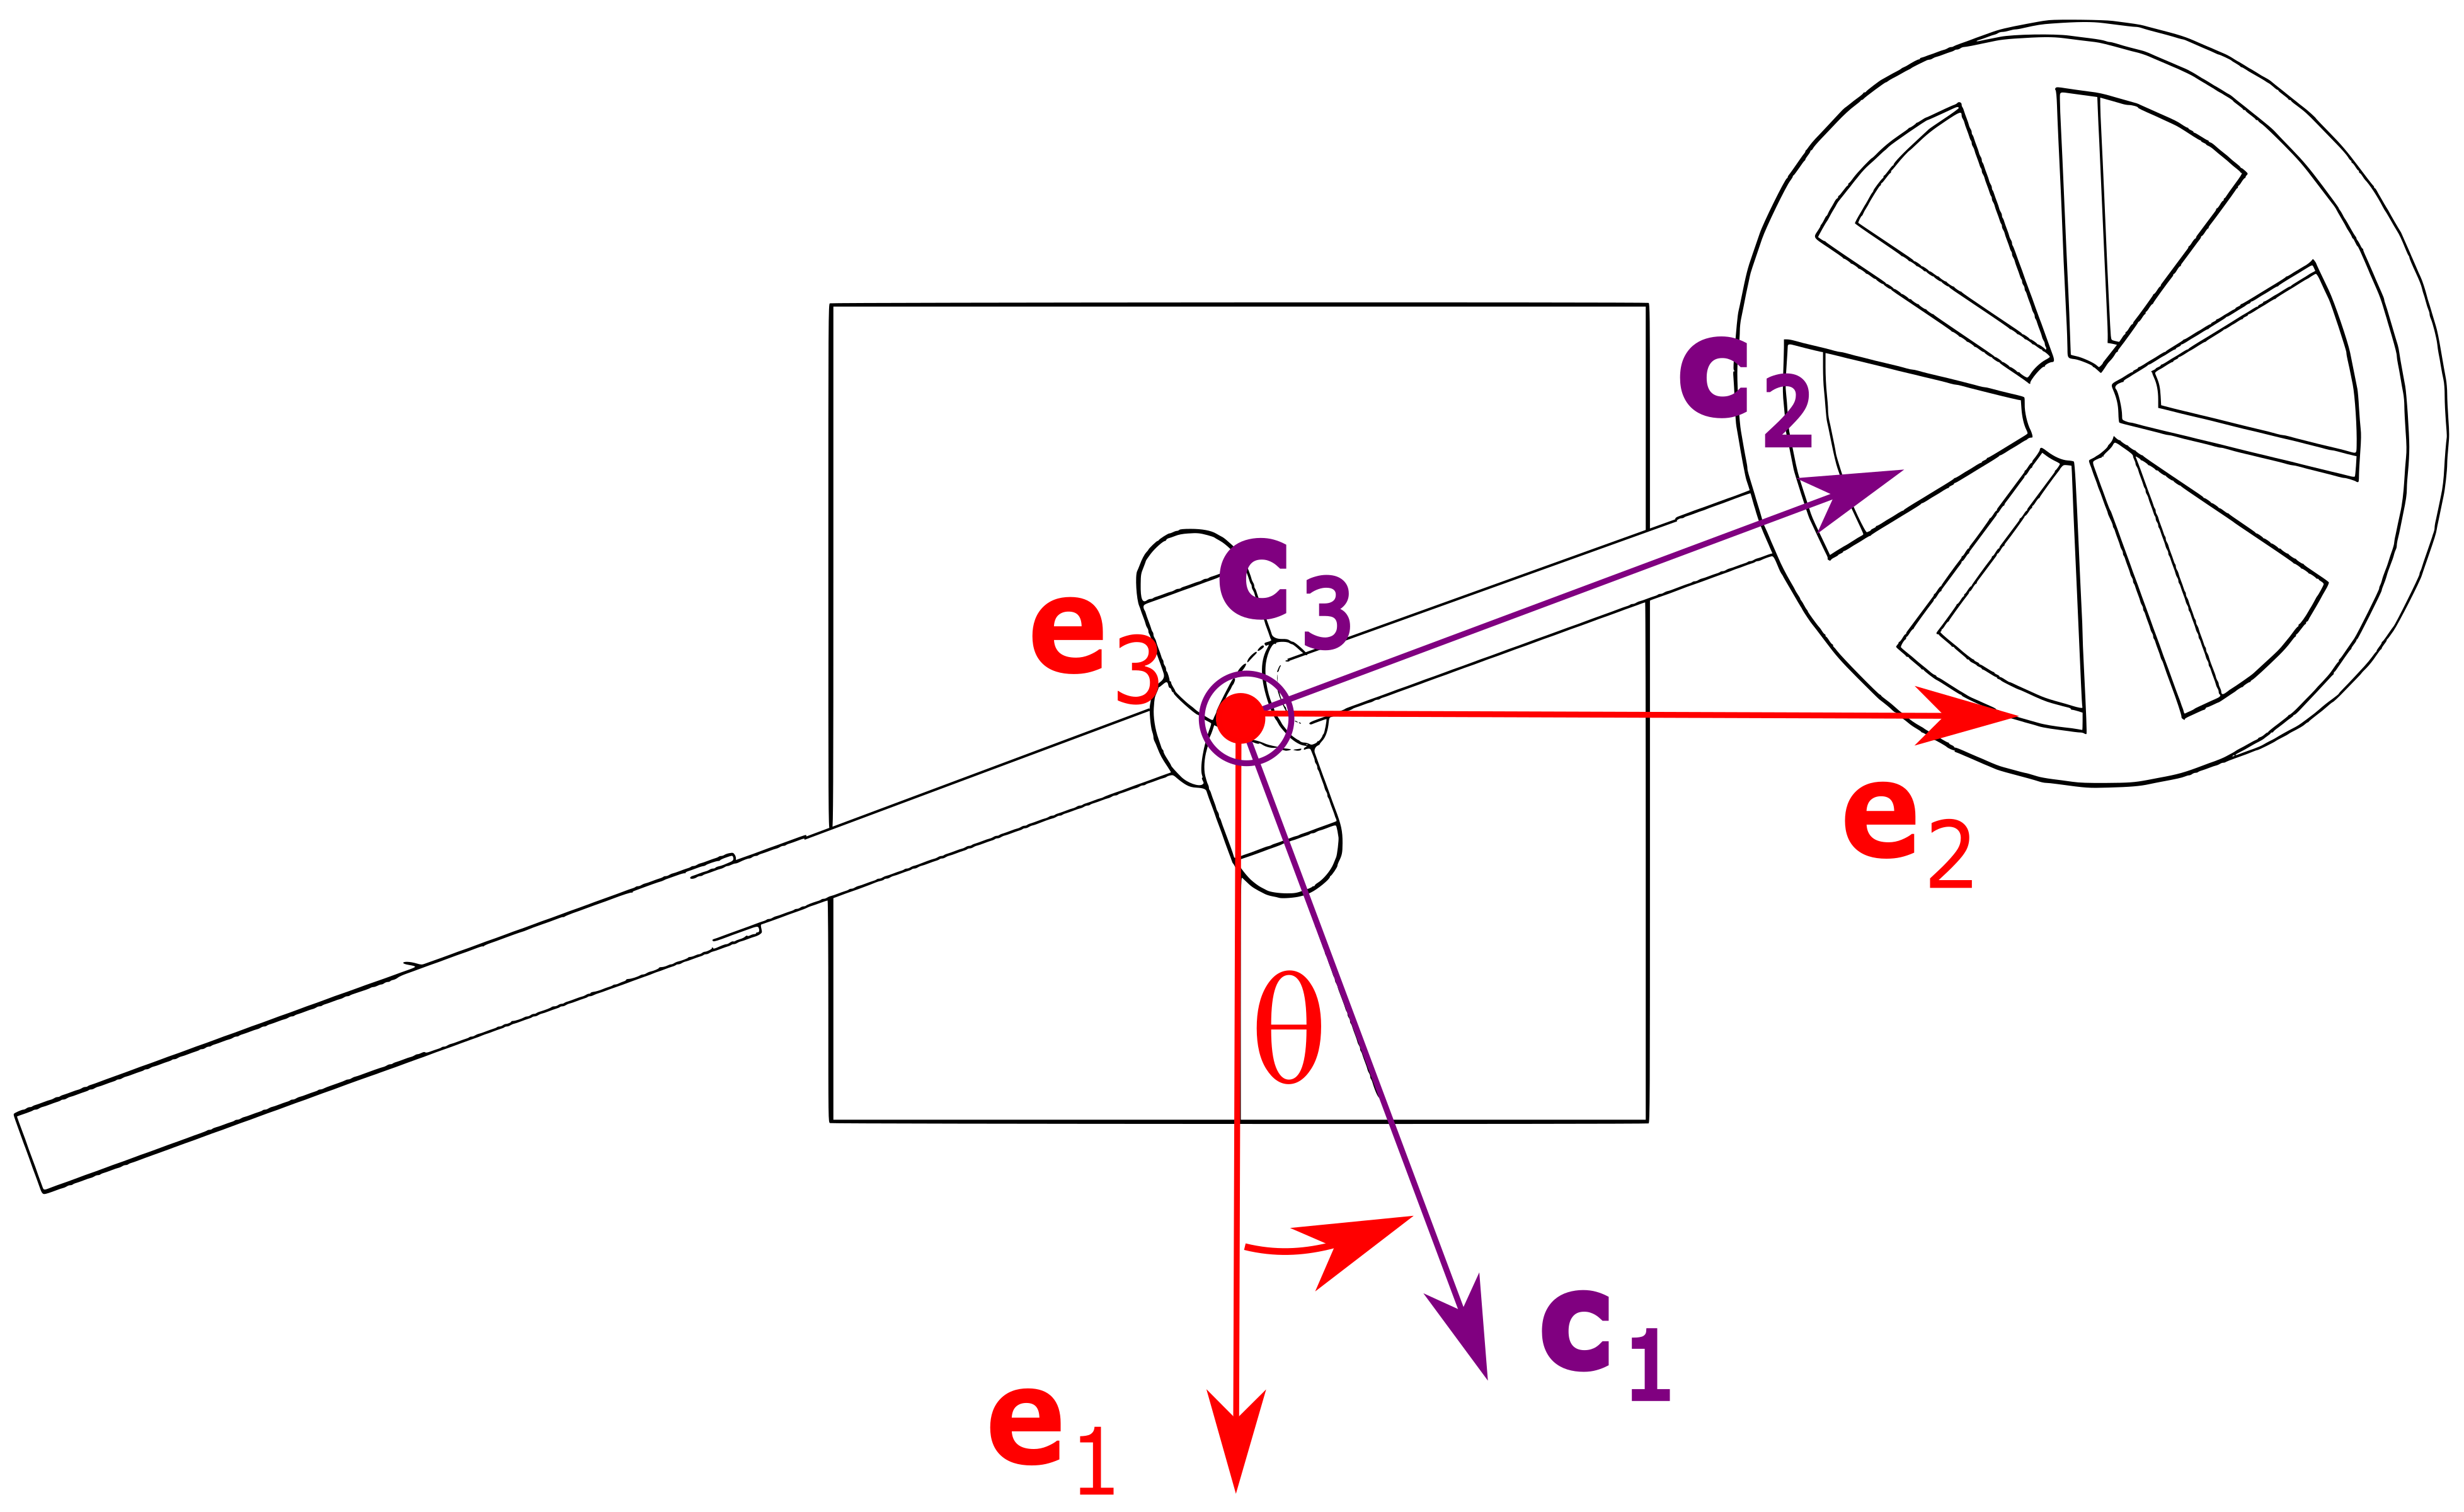

# The Configuration

Let us take inertial frame as $\mathbf{e}$, which is fixed to body part E. And $\mathbf{O}$ as the original of the $\mathbf{e}$-frame. Let $\mathbf{c}$ be another orthongonal frame such that it moves with respect to $\mathbf{e}$ in such a way that $\mathbf{c}_3\equiv \mathbf{e}_3$ and $\mathbf{c}$-frame is always fixed to body part c. Therefore

\begin{align*}
\mathbf{c}=\mathbf{e}\,R_3(\theta)
\end{align*}

\begin{align*}
R_3(\theta)=\begin{bmatrix}
\cos{\theta}&-\sin{\theta}&0\\
\sin{\theta}&\cos{\theta}&0\\
0&0&1
\end{bmatrix}.
\end{align*}

Let $\mathbf{b}$ be another orthonomal frame such that it moves with respect to $\mathbf{c}$ in such a way that $\mathbf{b}_1\equiv \mathbf{c}_1$ and $\mathbf{b}$ is always fixed to body part $\mathbf{B}$.

\begin{align*}
\mathbf{b}=\mathbf{c}\,R_1(\phi)
\end{align*}

\begin{align*}
R_1(\phi)=\begin{bmatrix}
1&0&0\\
0&\cos{\phi}&-\sin{\phi}\\
0&\sin{\phi}&\cos{\phi}
\end{bmatrix}.
\end{align*}

Origin of $\mathbf{e}$-frame and $\mathbf{c}$-frame coincide with each other. Let's take B as the origin of $\mathbf{b}$-frame.

\begin{align*}
\mathbf{b}=\mathbf{c}R_3(\theta)=\mathbf{e}R_1(\phi)R_3(\theta)=\mathbf{e}R
\end{align*}

Which gives

\begin{align*}
R=R_3(\theta)R_1(\phi)
\end{align*}

\begin{align*}
\dot{R}=\dot{R}_3R_1+R_3\dot{R}_1=R_3\widehat{\Omega}_3R_1+R_3{R}_1\widehat{\Omega}_1=R\widehat{\Omega}
\end{align*}

\begin{align*}
\widehat{\Omega}=R_1^T\widehat{\Omega}_3R_1+\widehat{\Omega}_1
\end{align*}

which gives
\begin{align*}
\Omega&=\dot{\theta}R_1^T(\phi)\:e_3+\dot{\phi}\:e_1,\\
&= \begin{bmatrix}
\dot{\phi}\\
\dot{\theta}\sin{(\phi)}\\
\dot{\theta}\cos{(\phi)}
\end{bmatrix}
\end{align*}


The angular momentum in $\mathbf{e}$ is
\begin{align}
\pi&=R\mathbb{I}\Omega
\end{align}

# The constraint moment

The constriant moment acting on the system prevents a rotation about $\mathbf{b}_2$. Thus
\begin{align}
\tau^e=R\begin{bmatrix}0\\T_2\\0
\end{bmatrix}
\end{align}

# The actuation moments

\begin{align*}
\tau_u &=RT_u=R\begin{bmatrix}
u_1\cos{\alpha}-u_2\cos{\beta}\\
0\\
u_1\sin{\alpha}-u_2\sin{\beta}
\end{bmatrix}
\end{align*}

Thus for the controls to be implementable $T_u^Te_2=0$

\begin{align*}
\tau_u &=RT_u=\begin{bmatrix}
u_1\cos{\alpha}-u_2\cos{\beta}\\
0\\
u_1\sin{\alpha}-u_2\sin{\beta}
\end{bmatrix}\\
&=R\begin{bmatrix}
1 & 0\\
0 & 0\\
0 & 1
\end{bmatrix}
\begin{bmatrix}
\cos{\alpha} & -\cos{\beta}\\
\sin{\alpha} & -\sin{\beta}
\end{bmatrix}
\begin{bmatrix}
u_1\\ u_2
\end{bmatrix}
\end{align*}


# Equations of motion

\begin{align*}
\dot{R}=\widehat{\omega}R\\
\pi=R\mathbb{I}R^T\omega\\
\dot{\pi}=RT_u=\tau_u+\tau_e
\end{align*}

Thus we see that the constraint moment is
\begin{align}
T_2&=e_2^T R^T \dot{\pi}\\
&=e_2^T \left(\Omega \times \mathbb{I}\Omega+\mathbb{I}\dot{\Omega}
\right)
\end{align}

In [ ]:
R

In [ ]:
def externalForceModel(qq,parameters,X):
    R=X[0][0];
    M=parameters['M']; g=parameters['g']; CM=parameters['CM'];
    fe=np.array([0,0,0]);
    taue=np.array([0,0,0]);
    return [taue,fe]

def actuator(qq,parameters, t, X, taue,fe):
    R=X[0][0];
    alpha=parameters['alpha']; beta=parameters['beta'];
    u1=0.01; u2=0.01
    tauu=R @ [u1*np.cos(alpha)-u2*np.cos(beta),0,u1*np.sin(alpha)-u2*np.sin(beta)]
    fu=np.array([0,0,0]);
    return [tauu,fu]

mr.set_external_force_model(externalForceModel)
mr.set_actuator(actuator)


In [ ]:
cubeDimensions={'l':4,'w':2,'h':1,'xp':2.,'yp':1.,'zp':0.5,};
parameters={'CM':np.array([cubeDimensions['l']/2-cubeDimensions['xp'],cubeDimensions['w']/2-cubeDimensions['yp'],cubeDimensions['h']/2-cubeDimensions['zp']]), 'g':1, 'M':1, 'II':np.array([[1.,0.,0.],[0.,1.,0.],[0.,0.,1.]])};
parameters.update({'alpha':1*np.pi/6,'beta':0*np.pi/6})
ICq=mr.q_from_axis_angles(0.,np.array([1,0,0]));
ICR=mr.r_from_quaternions(ICq);
ICOmega=np.array([0.,0.,0.]); ICo=np.array([0.,0.,0.]); ICp=np.array([0.,0.,0.]);
ICXC=np.array([0,0,0]);
ICs=[[ICR,ICo],ICR@ICOmega,ICp,ICXC]

In [ ]:
parameters

In [ ]:
aa4=mr.simulating_a_cube(0.1, 150., cubeDimensions, parameters,ICs)
fig1=mr.animated_cube_flat_shading(aa4,'Twin rotor as a box')

#Trajectory Tracking

In this section we investigate the problem of ensuring asymptotic tracking of a sufficiently smooth trajectory $R_r(t)$ in $\mathbb{R}^3\times SO(3)$.

##Configuration error

We notice that the configuration space $SO(3)$ is a group. It is closed under the multiplication operation defined as follows.

Now one can define the configuration error between a system configuration $R\in \mathbb{R}^3\times SO(3)$ and a reference configuration $R_r\in \mathbb{R}^3\times SO(3)$ in a global sense as  
\begin{align}
R_e\triangleq R^{-1}R_r\in  SO(3),
\end{align}
or alternatively as
\begin{align}
R_e\triangleq R_rR^{-1}\in SO(3),
\end{align}

The former is defined as the *left-invariant* error while the latter is defined as the *right-invariant* error.

Notice that both these errors are in the configuration space $SO(3)$ and not in the spatial momentum space of $SO(3)$.

##Tracking error dynamics

Let $R_r(t)$ be a desired trajectory and $\omega_r(t)$ be such that $\widehat{\omega}_r(t)=\dot{R}_rR_r^T$. In line with the system define the reference spatial angular momentum $\pi_r\triangleq R_r\mathbb{I}R_r^T\omega_r$

Define the configurarion error
\begin{align}
R_e&=R_rR^T.
\end{align}
Then the spatial angular velcity of the tracking error is defined by
\begin{align}
\widehat{\omega}_e&\triangleq \dot{R}_eR_e^T=\widehat{\omega}_r(t)-R_e\widehat{\omega}(t)R_e^T
\end{align}
and hence that
\begin{align}
\omega_e&=\omega_r-R_e\omega.
\end{align}
Define the angular momentum error as
\begin{align}
\pi_e\triangleq R\mathbb{I}R_r^T\omega_e=R\mathbb{I}R_r^T(\omega_r-R_e\omega)=R\mathbb{I}R_r^T\omega_r-R\mathbb{I}R^T\omega=R_e^T\pi_r-\pi.
\end{align}


Differentiating $\pi_e$ we have
\begin{align}
\dot{\pi}_e&=R_e^T(\dot{\pi}_r-\omega_e\times \pi_r)-\dot{\pi}=R_e^T(R_r\dot{\Pi}_r+(\omega_r-\omega_e)\times \pi_r)-\dot{\pi}=(R\dot{\Pi}_r+\omega\times R_e^T\pi_r)-\dot{\pi}
\end{align}



Thus we have the error dynamics
\begin{align}
\dot{R}_e&=\widehat{\omega}_eR_e,\\
\dot{\pi}_e&=(R\dot{\Pi}_r+\omega\times R_e^T\pi_r)-\tau_u-\tau_e
\end{align}

## Feedforward plus PID control

\begin{align}
\dot{e}_{I_R}&=e_R,\\
\tau_u&=-
\tau_e+(R\dot{\Pi}_r+\omega\times R_e^T\pi_r)+k_{P_R}e_R+k_{D_R}\pi_e+k_{I_R}e_{I_R}
\end{align}

### The proportional term

Let
\begin{align}
K&=\mathrm{diag}\{\mathbb{K}_1,\mathbb{K}_2,\mathbb{K}_3\}.
\end{align}

for some three distinct constants $\mathbb{K}_1,\mathbb{K}_2,\mathbb{K}_3$.

Then $e_R$ is given by
\begin{align}
\widehat{e}_R&=\frac{1}{2}\left(R_eK-KR_e^T\right).
\end{align}


## Implementation

To implement we need $R_e, \pi_e, e_R$ using the measurments $\theta, \phi, \dot{\theta}, \dot{\phi},$

\begin{align*}
R_e&=R_rR^T=R_3(\theta_r)R_1(\phi_r)R_1^T(\phi)R_3^T(\theta)=R_3(\theta_r)R_1(\phi_r-\phi)R_3^T(\theta)
\end{align*}
\begin{align*}
\Omega=R_1^T(\phi)\Omega_3+{\Omega}_1=R_1^T\begin{bmatrix}0\\0\\\dot{\theta}
\end{bmatrix}+\begin{bmatrix}\dot{\phi}\\0\\0
\end{bmatrix}
\end{align*}
\begin{align*}
\pi=R\mathbb{I}\Omega
\end{align*}
\begin{align*}
\pi_e=R_e^T\pi_r-\pi.
\end{align*}

\begin{align}
\dot{e}_{I_R}&=e_R,\\
\tau_u&=(R\dot{\Pi}_r+\omega\times R_e^T\pi_r)+k_{P_R}e_R+k_{D_R}\pi_e+k_{I_R}e_{I_R}
\end{align}

We will just note for completeness that the $\mathbf{b}$ frame version of the control is $T_u=R^T\tau_u$ that is  explicitly given by

\begin{align}
T_u&=(\dot{\Pi}_r+\Omega\times \Pi_r)+k_{P_R}R^Te_R+k_{D_R}(\Pi_r-\mathbb{I}\Omega)+k_{I_R}R^Te_{I_R}
\end{align}

### Implementation

Recall that
\begin{align}
R^T\tau_u=T_u=\begin{bmatrix}
u_1\cos{\alpha}-u_2\cos{\beta}\\
0\\
u_1\sin{\alpha}-u_2\sin{\beta}
\end{bmatrix}
\end{align}

For simplicity we will set $\beta=\alpha$ then we have
\begin{align}
R^T\tau_u=T_u=\begin{bmatrix}
(u_1-u_2)\cos{\alpha}\\
0\\
(u_1-u_2)\sin{\alpha}
\end{bmatrix}
\end{align}

Denote by $u_{-}=(u_1-u_2)$ and $u_{+}=(u_1+u_2)$ then we have
\begin{align}
u_{-}&=\sqrt{e_1^TR^T\tau_u}\\
\tan{(\alpha)}&=\frac{e_3^TR^T\tau_u}{e_1^TR^T\tau_u}
\end{align}

## SImulations

In [ ]:
def actuator(qq,parameters, t, X, taue,fe):
  Uc=controller(qq, parameters, t, X, taue,fe);
  tauu=Uc[0]; fu=Uc[1]
  return [tauu,fu]

def referenceConfig(qq,refParameters,t):
    II=refParameters;
    dotOmegart=np.array([.0,.0,0.0]);
    dotPir=II@dotOmegart;
    Omegart=np.array([0.0,0,0.0])+dotOmegart*t;
    Pir=II@Omegart;
    thetaOmegart=linalg.norm(Omegart)*t+0.2*np.pi;

    Omegart=np.array([0,0,1]) #If constant ref attitude uncomment
    nOmegart=Omegart/(0.000001+linalg.norm(Omegart));


    qOmegart=np.concatenate(([np.cos(thetaOmegart/2)],np.sin(thetaOmegart/2)*nOmegart));
    Rr=qq.r_from_quaternions(qOmegart);
    return [Rr,Pir,dotPir]

def controller(qq,parameters,t,X,taue,fe):

    #Fully Actuated PD Controller
    II=parameters['II'];
    R=X[0][0]; omega=X[1]; piI=X[3];
    [Rr,Pir,dotPir]=referenceConfig(qq,II,t);
    #print(Rr)
    pir=Rr@Pir;
    omegar=Rr@linalg.inv(II)@Pir;
    Re=Rr@R.T;
    pie=R @ II @ Rr.T @ (omegar-Re@omega);
    K=np.array([[1,0,0],[0,2,0],[0,0,3]]);
    eRhat=0.5*(Re@K-K@Re.T);
    eR=np.array([-eRhat[1,2],eRhat[0,2],-eRhat[0,1]]);
    tauu_nom=(R@dotPir+qq.hat_matrix(omega)@Re.T@pir)-taue+(4*eR+10*pie+2.*piI)
    Tu_nom=R.T@ tauu_nom
    u_plus=0.
    u_minus=np.sqrt(Tu_nom[0]**2+Tu_nom[2]**2)
    alpha=np.atan2(Tu_nom[2],Tu_nom[0]);
    tauu=R@np.array([u_minus*np.cos(alpha),0,u_minus*np.sin(alpha)])
    fu=-fe+np.array([0,0,0]);
    return [tauu,fu,eR,pie]

def controller_dynamics(qq, t,X,taue,fe,parameters):
    Xc=X[3];
    Uc=controller(qq,parameters,t,X,taue,fe);
    eR=Uc[2];
    dXc=eR;
    #print(eR)
    return dXc


mr.set_actuator(actuator)

In [ ]:
cubeDimensions={'l':2,'w':4,'h':1,'xp':1.,'yp':2.,'zp':0.5,};
parameters={'CM':np.array([cubeDimensions['l']/2-cubeDimensions['xp'],cubeDimensions['w']/2-cubeDimensions['yp'],cubeDimensions['h']/2-cubeDimensions['zp']]), 'g':1, 'M':1, 'II':np.array([[1.,0.,0.],[0.,1.,0.],[0.,0.,1.]])};
ICq=mr.q_from_axis_angles(0.,np.array([1,0,0]));
ICR=mr.r_from_quaternions(ICq);
ICOmega=np.array([0.,0.,0.]); ICo=np.array([0.,0.,0.]); ICp=np.array([0.,0.,0.]);
ICXC=np.array([0,0,0]);
ICs=[[ICR,ICo],ICR@ICOmega,ICp,ICXC]

In [ ]:
aa4=mr.simulating_a_cube(0.1, 50., cubeDimensions, parameters,ICs)
fig1=mr.animated_cube_flat_shading(aa4,'Twin rotor as a box pivoted at the center')